In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch
from qwen_vl_utils import process_vision_info

In [187]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Set False for 8-bit
    bnb_4bit_compute_dtype=torch.float16
)

In [188]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct", torch_dtype="auto", device_map="auto", quantization_config=bnb_config,
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [189]:
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

In [ ]:
img_name = "03236_00.jpg"
cloth_path = f"./data/train/cloth/{img_name}"
image_path = f"./data/train/image/{img_name}"

In [191]:
tagging_prompt = """Please tag the cloth in the image in terms of brand, sleeve, neckline, primary color, secondary color, and casuality.
Examples: 1. Calvin Klein, long sleeve, v-neck, black, 2. Levi's, short sleeve, round neck, blue, white, casual

Note: If brand name is not present, please use "Unknown" as the brand name. Do not add new schema.
Please use the following format: [tag1, tag2, tag3, ...].
Do not include any other text in your response."""

In [192]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": cloth_path
            },
            {"type": "text", "text": tagging_prompt},
        ],
    }
]

In [193]:
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

In [194]:
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
description_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
tag_text = description_text[0]
print(tag_text)

Unknown, long sleeve, turtleneck, gray, gray, casual


In [195]:
attr_prompt = """Please tag the person's attributes in the image in terms of fit, pants color, and hair color.
Examples: 1. loose fit, red, black 2. tight fit, black, blonde

Please use the following format: [tag1, tag2, tag3, ...].
Do not include any other text in your response."""

In [196]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path
            },
            {"type": "text", "text": attr_prompt},
        ],
    }
]

text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
description_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
attribute_text = description_text[0]
print(attribute_text)

tight fit, black, brown


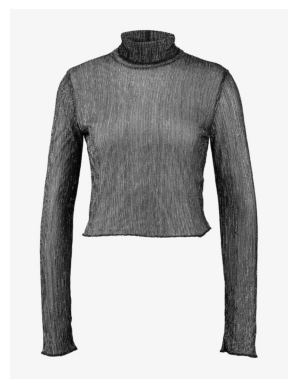

In [197]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(cloth_path)
plt.imshow(image)
plt.axis('off')
plt.show()

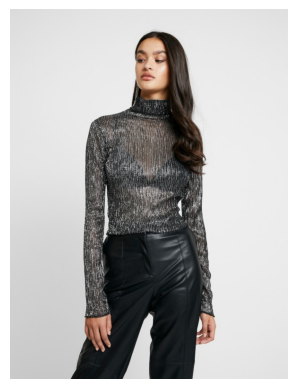

In [198]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

In [201]:
to_strip = "[]"
tag_text = tag_text.strip(to_strip)
attribute_text = attribute_text.strip(to_strip)
data_text = img_name + ", " + tag_text + ", " + attribute_text

In [202]:
data_text

'00023_00.jpg, Unknown, long sleeve, turtleneck, gray, gray, casual, tight fit, black, brown'

00000_00.jpg
